# Homework 5


## Question 1


Problem 1: Linear SVM
  Hard-margin (C=1e-05): Accuracy = 0.9200
  Soft-margin C=1 (C=1): Accuracy = 0.9933
  Soft-margin C=800 (C=800): Accuracy = 0.9867

Problem 2: Nonlinear SVM
  RBF kernel {'gamma': 0.7}, C=1e-05: Accuracy = 0.9533
  RBF kernel {'gamma': 0.7}, C=1: Accuracy = 0.9800
  POLY kernel {'degree': 4}, C=1e-05: Accuracy = 0.6400
  POLY kernel {'degree': 4}, C=1: Accuracy = 0.9800

Problem 3: Best model identification
  Best model: Linear Soft-margin C=1 with Accuracy = 0.9933

Problem 4: KNN decision boundaries
  k = 10, grid shape = (220, 280)


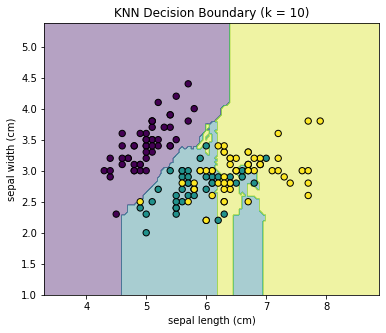

  k = 20, grid shape = (220, 280)


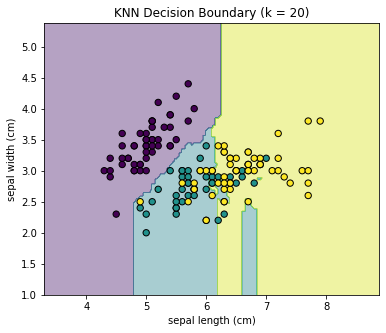

  k = 30, grid shape = (220, 280)


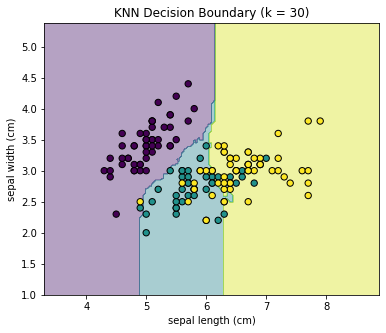

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Problem 1: Linear SVM-based three-class classification
print("Problem 1: Linear SVM")
for C, desc in [(1e-5, "Hard-margin"), (1, "Soft-margin C=1"), (800, "Soft-margin C=800")]:
    clf = SVC(kernel="linear", C=C)
    clf.fit(X, y)
    acc = accuracy_score(y, clf.predict(X))
    print(f"  {desc} (C={C}): Accuracy = {acc:.4f}")

# Problem 2: Nonlinear SVM-based three-class classification
print("\nProblem 2: Nonlinear SVM")
for kernel, params, C in [
    ("rbf",  {"gamma": 0.7}, 1e-5),
    ("rbf",  {"gamma": 0.7}, 1),
    ("poly", {"degree": 4}, 1e-5),
    ("poly", {"degree": 4}, 1)
]:
    clf = SVC(kernel=kernel, C=C, **params)
    clf.fit(X, y)
    acc = accuracy_score(y, clf.predict(X))
    print(f"  {kernel.upper()} kernel {params}, C={C}: Accuracy = {acc:.4f}")

# Problem 3: Compare accuracies and identify best model
print("\nProblem 3: Best model identification")
models = []
# Linear SVMs
for C, desc in [(1e-5, "Linear Hard-margin"), (1, "Linear Soft-margin C=1"), (800, "Linear Soft-margin C=800")]:
    acc = accuracy_score(y, SVC(kernel="linear", C=C).fit(X, y).predict(X))
    models.append((desc, acc))
# Nonlinear SVMs
for kernel, params, C in [
    ("RBF",  {"gamma": 0.7}, 1e-5),
    ("RBF",  {"gamma": 0.7}, 1),
    ("POLY", {"degree": 4}, 1e-5),
    ("POLY", {"degree": 4}, 1)
]:
    acc = accuracy_score(y, SVC(kernel=kernel.lower(), C=C, **params).fit(X, y).predict(X))
    models.append((f"{kernel} {params} C={C}", acc))
# Find and print best
best_desc, best_acc = max(models, key=lambda x: x[1])
print(f"  Best model: {best_desc} with Accuracy = {best_acc:.4f}")

# Problem 4: KNN-based three-class classification and plotting decision regions
print("\nProblem 4: KNN decision boundaries")
# Use only the first two features for visualization
X2 = X[:, :2]
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

for k in [10, 20, 30]:
    knn = KNeighborsClassifier(n_neighbors=k, p=1, metric='minkowski')
    knn.fit(X2, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    print(f"  k = {k}, grid shape = {Z.shape}")
    
    # Plot
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X2[:, 0], X2[:, 1], c=y, edgecolor='k', s=40)
    plt.title(f'KNN Decision Boundary (k = {k})')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()